# Analysis of Chest X-Ray images

The objective is to identify images where an "effusion" is present. This is a classification problem, where we will be dealing with two classes - 'effusion' and 'nofinding.

## 1. Data Pre-processing

Our data is in the form of grayscale (black and white) images of chest x-rays. To perform our classification task effectively, we need to perform some pre-processing of the data.

First, we load all the relevant libraries.

In [1]:
from skimage import io
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')

Point a variable to the path where the data resides. Note that to use the code below you will need to move the folders effusion/ and nofinding/ into one common folder. You can do something like this:

```
mkdir CXR_Data
move effusion CXR_Data
move nofinding CXR_Data
```

In [5]:
!unzip CXR_Data.zip


Archive:  CXR_Data.zip
   creating: CXR_Data/effusion/
  inflating: CXR_Data/effusion/00006592_000.png  
  inflating: CXR_Data/effusion/00006596_000.png  
  inflating: CXR_Data/effusion/00006600_000.png  
  inflating: CXR_Data/effusion/00006626_000.png  
  inflating: CXR_Data/effusion/00006649_000.png  
  inflating: CXR_Data/effusion/00006663_000.png  
  inflating: CXR_Data/effusion/00006667_000.png  
  inflating: CXR_Data/effusion/00006705_000.png  
  inflating: CXR_Data/effusion/00006708_000.png  
  inflating: CXR_Data/effusion/00006713_000.png  
  inflating: CXR_Data/effusion/00006741_000.png  
  inflating: CXR_Data/effusion/00006744_000.png  
  inflating: CXR_Data/effusion/00006754_000.png  
  inflating: CXR_Data/effusion/00006819_000.png  
  inflating: CXR_Data/effusion/00006848_000.png  
  inflating: CXR_Data/effusion/00006857_000.png  
  inflating: CXR_Data/effusion/00006862_000.png  
  inflating: CXR_Data/effusion/00006864_000.png  
  inflating: CXR_Data/effusion/00006873_000.p

In [6]:
!rm CXR_Data.zip

In [7]:
DATASET_PATH = './CXR_data/'

# There are two classes of images that we will deal with
disease_cls = ['effusion', 'nofinding']

Next, we read the "effusion" and "nofinding" images.

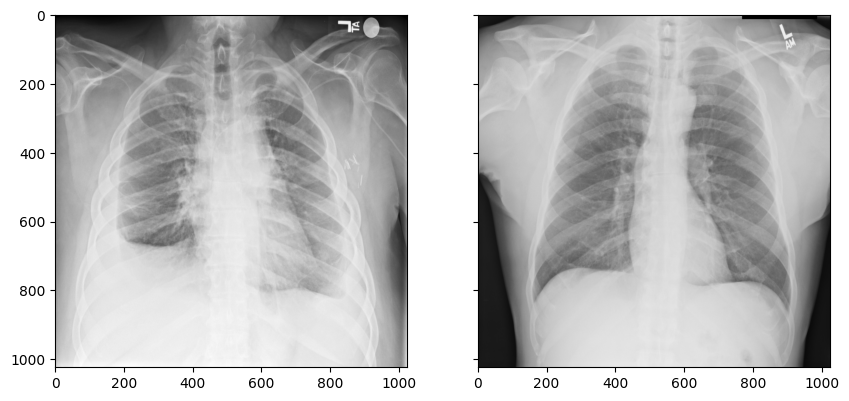

In [8]:
effusion_path = os.path.join(DATASET_PATH, disease_cls[0], '*')
effusion = glob.glob(effusion_path)
effusion = io.imread(effusion[0])

normal_path = os.path.join(DATASET_PATH, disease_cls[1], '*')
normal = glob.glob(normal_path)
normal = io.imread(normal[0])

f, axes = plt.subplots(1, 2, sharey=True)
f.set_figwidth(10)
    
axes[0].imshow(effusion, cmap='gray')
axes[1].imshow(normal, cmap='gray')

In [9]:
effusion.shape

(1024, 1024)

In [10]:
normal.shape

(1024, 1024)

### Data Augmentation ###

Now that we have read the images, the next step is data augmentation. We use the concept of a "data generator" that you learnt in the last section.

In [17]:
from skimage.transform import rescale
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    rotation_range=10,
    width_shift_range=0,
    height_shift_range=0,
    vertical_flip=False,)

def preprocess_img(img, mode):
    img = (img - img.min())/(img.max() - img.min())
    img = rescale(img, 0.25, channel_axis=-1, mode='constant')
    
    if mode == 'train':
        if np.random.randn() > 0:
            img = datagen.random_transform(img)
    return img

## 2. Model building

In [18]:
import resnet

img_channels = 1
img_rows = 256
img_cols = 256

nb_classes = 2

In [21]:
import numpy as np
import tensorflow as tf

class AugmentedDataGenerator(tf.keras.utils.Sequence):
    'Generates data for Keras'
    def __init__(self, mode='train', ablation=None, disease_cls = ['effusion','nofinding'], 
                 batch_size=32, dim=(256, 256), n_channels=1, shuffle=True):
        'Initialization'
        self.dim = dim
        self.batch_size = batch_size
        self.labels = {}
        self.list_IDs = []
        self.mode = mode
        
        for i, cls in enumerate(disease_cls):
            paths = glob.glob(os.path.join(DATASET_PATH, cls, '*'))
            brk_point = int(len(paths)*0.8)
            if self.mode == 'train':
                paths = paths[:brk_point]
            else:
                paths = paths[brk_point:]
            if ablation is not None:
                paths = paths[:int(len(paths)*ablation/100)]
            self.list_IDs += paths
            self.labels.update({p:i for p in paths})
        
            
        self.n_channels = n_channels
        self.n_classes = len(disease_cls)
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch'
        return max(1,int(np.floor(len(self.list_IDs) / self.batch_size)))

    def __getitem__(self, index):
        'Generate one batch of data'

        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        list_IDs_temp = [self.list_IDs[k] for k in indexes]

        X, y = self.__data_generation(list_IDs_temp)

        return X, y

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __data_generation(self, list_IDs_temp):
        'Generates data containing batch_size samples' # X : (n_samples, *dim, n_channels)
        # Initialization
        X = np.empty((self.batch_size, *self.dim, self.n_channels))
        y = np.empty((self.batch_size), dtype=int)
        
        delete_rows = []

        # Generate data
        for i, ID in enumerate(list_IDs_temp):
            img = io.imread(ID)
            img = img[:, :, np.newaxis]
            if img.shape == (1024, 1024,1):
                img = preprocess_img(img, self.mode)
                X[i,] = img
                y[i] = self.labels[ID]
            else:
                delete_rows.append(i)
                continue
                
        X = np.delete(X, delete_rows, axis=0)
        y = np.delete(y, delete_rows, axis=0)
        
        return X, tf.keras.utils.to_categorical(y, num_classes=self.n_classes)

## 3. Ablation Run

In the previous notebook, you learnt about Ablation. Briefly, an ablation run is when you systematically modify certain parts of the input, in order to observe the equivalent change in the input.

For the following section, we'll be using the Data Generator concept that you previously worked on.

In [22]:
model = resnet.ResnetBuilder.build_resnet_18((img_rows, img_cols,img_channels), nb_classes)
model.compile(loss='categorical_crossentropy',optimizer='SGD',
              metrics=['accuracy'])
training_generator = AugmentedDataGenerator('train', ablation=5)
validation_generator = AugmentedDataGenerator('val', ablation=5)

model.fit(training_generator, epochs=1, validation_data=validation_generator)

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.9032 - loss: 1.4679 - val_accuracy: 0.9062 - val_loss: 1.8175


In [24]:
model = resnet.ResnetBuilder.build_resnet_18((img_rows, img_cols,img_channels), nb_classes)
model.compile(loss='categorical_crossentropy',optimizer='SGD',
              metrics=['accuracy'])

training_generator = AugmentedDataGenerator('train', ablation=5)
validation_generator = AugmentedDataGenerator('val', ablation=5)

model.fit(training_generator, epochs=5, validation_data=None)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.5000 - loss: 1.6691
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.9032 - loss: 1.4255
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.9355 - loss: 1.3194
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.9375 - loss: 1.2789
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.9062 - loss: 1.2873


In [25]:
from sklearn.metrics import roc_auc_score
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import *

class roc_callback(Callback):
    
    def on_train_begin(self, logs={}):
        logs['val_auc'] = 0

    def on_epoch_end(self, epoch, logs={}):
        y_p = []
        y_v = []
        for i in range(len(validation_generator)):
            x_val, y_val = validation_generator[i]
            y_pred = self.model.predict(x_val)
            y_p.append(y_pred)
            y_v.append(y_val)
        y_p = np.concatenate(y_p)
        y_v = np.concatenate(y_v)
        roc_auc = roc_auc_score(y_v, y_p)
        print ('\nVal AUC for epoch{}: {}'.format(epoch, roc_auc))
        logs['val_auc'] = roc_auc

In [26]:
model = resnet.ResnetBuilder.build_resnet_18((img_rows, img_cols,img_channels), nb_classes)
model.compile(loss='categorical_crossentropy',optimizer='SGD',
              metrics=['accuracy'])

training_generator = AugmentedDataGenerator('train', ablation=20)
validation_generator = AugmentedDataGenerator('val', ablation=20)

auc_logger = roc_callback()

model.fit(training_generator, epochs=5, validation_data=validation_generator, callbacks=[auc_logger])

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Val AUC for epoch0: 0.5166666666666667
5/5 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.8506 - loss: 1.4167 - val_accuracy: 0.8750 - val_loss: 4.0157 - val_auc: 0.5167
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step

Val AUC for epoch1: 0.5545977011494253
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.8903 - loss: 1.3143 - val_accuracy: 0.9062 - val_loss: 2.4154 - val_auc: 0.5546
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step

Val AUC for epoch2: 0.7096774193548387
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.9032 - loss: 1.2839 - val_accuracy: 0.8750 - val_loss: 2.3807 - val_auc: 0.7097
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step

Val AUC for epoch3: 0.5287356321839081
5/5 ━━━━━━━━━━━━━━━━━━━━ 26s 5s/step - accuracy: 0.9091 - loss: 1.2594 - val_accuracy: 0.9062 - val_loss: 1.7694 - val_auc: 0.5287
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step

Val AUC for epoch4: 0.2413793103448276
5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/st

In [27]:
from functools import partial
import tensorflow.keras.backend as K
from itertools import product

def w_categorical_crossentropy(y_true, y_pred, weights):
    nb_cl = len(weights)
    final_mask = K.zeros_like(y_pred[:, 0])
    y_pred_max = K.max(y_pred, axis=1)
    y_pred_max = K.reshape(y_pred_max, (K.shape(y_pred)[0], 1))
    y_pred_max_mat = K.cast(K.equal(y_pred, y_pred_max), K.floatx())
    for c_p, c_t in product(range(nb_cl), range(nb_cl)):
        final_mask += (weights[c_t, c_p] * y_pred_max_mat[:, c_p] * y_true[:, c_t])
    cross_ent = K.categorical_crossentropy(y_true, y_pred, from_logits=False)
    return cross_ent * final_mask

bin_weights = np.ones((2,2))
bin_weights[0, 1] = 5
bin_weights[1, 0] = 5
ncce = partial(w_categorical_crossentropy, weights=bin_weights)
ncce.__name__ ='w_categorical_crossentropy'

In [28]:
model = resnet.ResnetBuilder.build_resnet_18((img_rows, img_cols,img_channels), nb_classes)
model.compile(loss=ncce, optimizer='SGD',
              metrics=['accuracy'])

training_generator = AugmentedDataGenerator('train', ablation=5)
validation_generator = AugmentedDataGenerator('val', ablation=5)

model.fit(training_generator, epochs=1, validation_data=None)

1/1 ━━━━━━━━━━━━━━━━━━━━ 32s 32s/step - accuracy: 0.0938 - loss: 7.6239


## 4. Final Run

After deeply examining our data and building some preliminary models, we are finally ready to build a model that will perform our prediction task.

In [37]:
class DecayLR(tf.keras.callbacks.Callback):
    def __init__(self, base_lr=0.005, decay_epoch=3):
        super().__init__()
        self.base_lr = base_lr
        self.decay_epoch = decay_epoch
        self.lr_history = []

    def on_train_begin(self, logs=None):
        self.model.optimizer.learning_rate.assign(self.base_lr)

    def on_epoch_end(self, epoch, logs=None):
        new_lr = self.base_lr * (0.5 ** (epoch // self.decay_epoch))
        self.lr_history.append(
            float(self.model.optimizer.learning_rate.numpy())
        )
        self.model.optimizer.learning_rate.assign(new_lr)


In [38]:
model = resnet.ResnetBuilder.build_resnet_18((img_rows, img_cols,img_channels), nb_classes)
sgd = optimizers.SGD(learning_rate=0.005)

bin_weights = np.ones((2,2))
bin_weights[1, 1] = 10
bin_weights[1, 0] = 10
ncce = partial(w_categorical_crossentropy, weights=bin_weights)
ncce.__name__ ='w_categorical_crossentropy'

model.compile(loss=ncce,optimizer= sgd,
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
training_generator = AugmentedDataGenerator('train', ablation=50)
validation_generator = AugmentedDataGenerator('val', ablation=None)

auc_logger = roc_callback()
filepath = 'models/best_model.keras'
checkpoint = ModelCheckpoint(filepath, monitor='val_auc', verbose=1, save_best_only=True, mode='max')

decay = DecayLR()

model.fit(training_generator, epochs=10, validation_data=validation_generator, callbacks=[auc_logger, decay, checkpoint])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Val AUC for epoch0: 0.4404533844189017

Epoch 1: val_auc improved from None to 0.44045, saving model to models/best_model.keras

Epoch 1: finished saving model to models/best_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 224s 16s/step - accuracy: 0.8308 - auc: 0.8951 - loss: 2.1370 - val_accuracy: 0.8958 - val_auc: 0.4405 - val_loss: 2.2932
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Val AUC for epoch1: 0.44563953488372093

Epoch 2: val_auc improved from 0.44045 to 0.44564, saving model to models/best_model.keras

Epoch 2: finished saving model to models/best_model.keras
13/13 ━━━━━━━━━━━

## 5. Making a Prediction

In [40]:
val_model = resnet.ResnetBuilder.build_resnet_18((img_rows, img_cols,img_channels), nb_classes)
val_model.load_weights('models/best_model.keras')

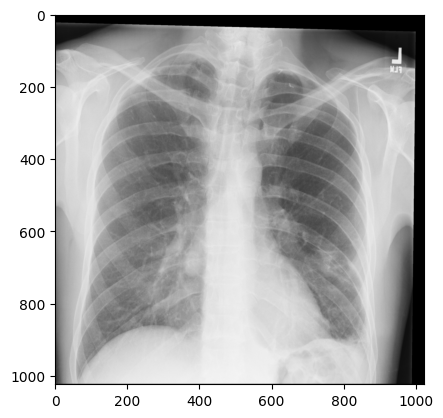

In [48]:
effusion_path = os.path.join(DATASET_PATH, disease_cls[0], '*')
effusion = glob.glob(effusion_path)
effusion = io.imread(effusion[-7])
plt.imshow(effusion,cmap='gray')

In [49]:
img = preprocess_img(effusion[:, :, np.newaxis], 'validation')
val_model.predict(img[np.newaxis,:])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


array([[0.08747794, 0.912522  ]], dtype=float32)